# NIFTY 500 Data Ingestion & Preprocessing

This notebook imports the `data_ingestion` pipeline to pull the NIFTY 500 constituents and download historical daily OHLC data from Yahoo Finance.

In [1]:
import os
import sys
import pandas as pd

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import ingestion functions
from src.pipeline.data_ingestion import fetch_nifty500_constituents, ingest_nifty500_data
# Import feature generation functions
from src.features.feature_generation import generate_all_features
from src.features.feature_hygiene import *

In [2]:
# Fetching the universe

universe_df= fetch_nifty500_constituents()
universe_df.head()

,Company Name,Industry,Symbol,Series,ISIN Code
0,360 ONE WAM Ltd.,Financial Services,360ONE,EQ,INE466L01038
1,3M India Ltd.,Diversified,3MINDIA,EQ,INE470A01017
2,ABB India Ltd.,Capital Goods,ABB,EQ,INE117A01022
3,ACC Ltd.,Construction Materials,ACC,EQ,INE012A01025
4,ACME Solar Holdings Ltd.,Power,ACMESOLAR,EQ,INE622W01025


In [3]:
# Fetch Historical OHLCV from Yfinance

start_date= "2018-01-01"
end_date= "2025-12-31"

ingest_nifty500_data(start_date= start_date, end_date= end_date)

[████████████████████████████████████████] 100.0% | 500/500 stocks processed

=== Ingested Dataset Summary ===
Shape: (813757, 11)
Unique Symbols Ingested: 500
Date Range: 2018-01-01 00:00:00 to 2025-12-30 00:00:00

Basic Statistics:
              Open         High          Low        Close        Volume  target_reg_1d  target_clf_1d  target_reg_5d  target_clf_5d
count  813757.0000  813757.0000  813757.0000  813757.0000  8.137570e+05    813257.0000    813257.0000    811257.0000    811257.0000
mean     1501.4899    1522.2877    1478.9820    1499.4941  5.873508e+06        -0.0014         0.4424         0.0024         0.4919
std      5775.8163    5838.3428    5705.5330    5767.9027  2.610098e+07         0.0241         0.4967         0.0584         0.4999
min         0.3500       0.4000       0.3500       0.4000  0.000000e+00        -0.5128         0.0000        -0.9493         0.0000
25%       147.4000     150.1933     144.5625     147.1259  2.072600e+05        -0.0139         0.0000     

In [4]:
parquet_path= os.path.join(project_root, "data", "raw", "nifty500_daily.parquet")
df_raw= pd.read_parquet(parquet_path)

In [5]:
# Adding features

df_feat= generate_all_features(df_raw)

df_feat.iloc[:6]

,Date,Open,High,Low,Close,Volume,Symbol,return_3d,log_return_3d,roc_3d,...,return_5d_lag3,return_5d_lag4,return_5d_lag5,day_of_week,month,year,target_reg_1d,target_reg_5d,target_clf_1d,target_clf_5d
0,2019-09-19,245.795521,258.085297,245.795521,258.085297,7109860,360ONE,NaN,NaN,NaN,...,NaN,NaN,NaN,3,9,2019,0.003762,0.005380,1,1
1,2019-09-20,269.968813,270.984497,269.968813,270.984497,2760648,360ONE,NaN,NaN,NaN,...,NaN,NaN,NaN,4,9,2019,0.000000,-0.071857,1,0
2,2019-09-23,284.533691,284.533691,284.533691,284.533691,34096,360ONE,NaN,NaN,NaN,...,NaN,NaN,NaN,0,9,2019,0.000000,-0.160230,1,0
3,2019-09-24,298.753296,298.753296,298.753296,298.753296,2496652,360ONE,0.157576,0.146328,0.157576,...,NaN,NaN,NaN,1,9,2019,-0.090176,-0.174783,0,0
4,2019-09-25,313.683900,313.683900,283.822784,285.397095,530580,360ONE,0.053186,0.051820,0.053186,...,NaN,NaN,NaN,2,9,2019,-0.013911,-0.048155,0,0
5,2019-09-26,275.250420,298.611156,271.136899,271.421295,78256,360ONE,-0.046084,-0.047179,-0.046084,...,NaN,NaN,NaN,3,9,2019,-0.025450,-0.040667,0,0


In [6]:
# Critical Verification Checklist

target_cols = [col for col in df_feat.columns if 'target_' in col]
feature_cols = [col for col in df_feat.columns if col not in target_cols and col not in ['Date', 'Symbol']]
print(f"Isolated {len(feature_cols)} input features.")
print(f"Isolated {len(target_cols)} target columns: {target_cols}")


Isolated 197 input features.
Isolated 4 target columns: ['target_reg_1d', 'target_reg_5d', 'target_clf_1d', 'target_clf_5d']


In [7]:
# Final cleaning removing nans and all

df_valid= df_feat.dropna(subset= target_cols)

print(f"Shape before dropping NaNs: {df_feat.shape}")
print(f"Shape after dropping NaNs: {df_valid.shape}")

Shape before dropping NaNs: (813757, 203)
Shape after dropping NaNs: (811257, 203)


In [8]:
# saving processed dir

processed_dir= os.path.join(project_root, "data", "processed")
os.makedirs(processed_dir, exist_ok= True)

processed_parquet_path= os.path.join(processed_dir, "nifty500_daily_features.parquet")
df_feat.to_parquet(processed_parquet_path, index= False)

In [9]:
train_df, holdout_df, test_df= chronological_split(df_valid, train_pct= 0.8, holdout_pct= 0.1, embargo_days= 5)

Percentage split calculated: Train end = 2024-05-24, Holdout end = 2025-03-06


Dropped 1 features due to high NaN ratio (>50%): ['kurt_3d']
  Iteration 1: Dropping 'macd_fast' with VIF = 529823688.16
  Iteration 20: Dropping 'High' with VIF = 27819.13
  Iteration 40: Dropping 'atr_20d' with VIF = 363.54
  Iteration 60: Dropping 'norm_vol_100d' with VIF = 64.77
  Iteration 80: Dropping 'vol_z_20d' with VIF = 26.60
  Iteration 100: Dropping 'log_return_200d' with VIF = 16.63
Collinearity filtering complete. Retained 82 / 197 features.


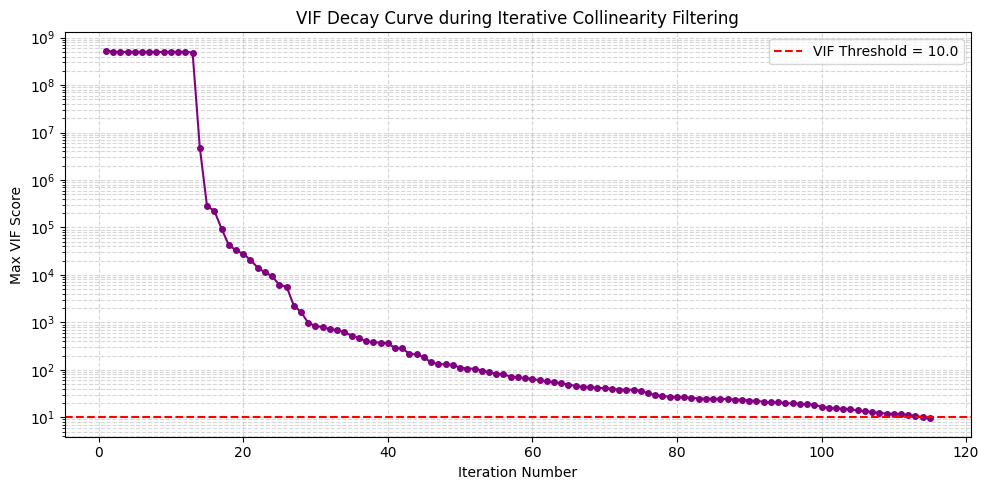

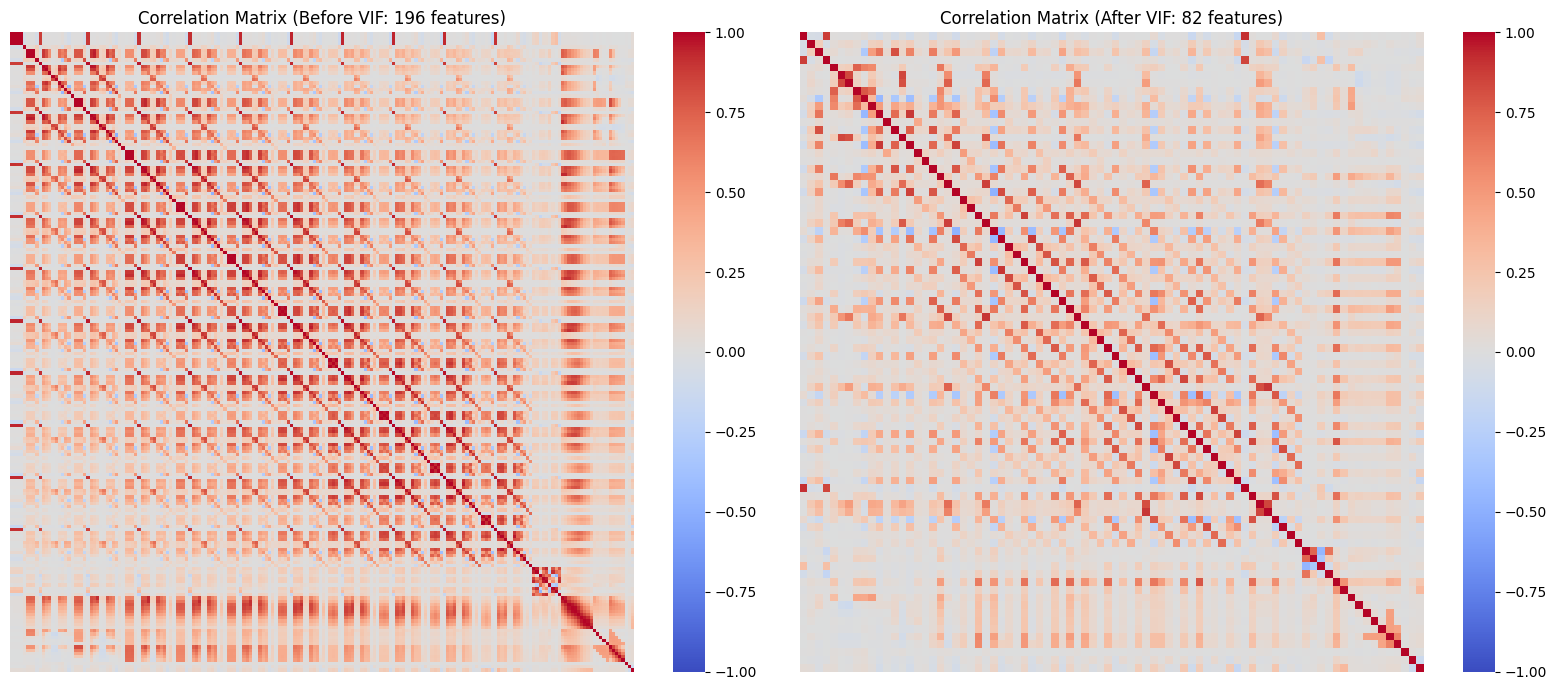

In [10]:
vif_features = filter_collinearity(train_df, feature_cols, threshold=10.0, plot= True)

In [11]:
train_df_clean= train_df.dropna(subset= vif_features)

df_feat_diff, optimal_d_dict= process_stationarity_and_diff(df_valid, train_df_clean, vif_features, max_workers= 8)

Reviewing stationarity for 82 features...
Stationarity review complete: 12 / 82 features are non-stationary.
  Feature 'Close' will be fractionally differentiated with d = 0.3
  Feature 'skew_100d' will be fractionally differentiated with d = 0.1
  Feature 'kurt_100d' will be fractionally differentiated with d = 0.1
  Feature 'return_200d' will be fractionally differentiated with d = 0.2
  Feature 'volatility_100d' will be fractionally differentiated with d = 0.3
  Feature 'max_ratio_200d' will be fractionally differentiated with d = 0.1
  Feature 'kurt_200d' will be fractionally differentiated with d = 0.1
  Feature 'skew_200d' will be fractionally differentiated with d = 0.2
  Feature 'volatility_200d' will be fractionally differentiated with d = 0.5
  Feature 'high_low_ratio_200d' will be fractionally differentiated with d = 0.3
  Feature 'atr_200d' will be fractionally differentiated with d = 0.7
  Feature 'year' will be fractionally differentiated with d = 0.3


In [12]:
train_df_diff, holdout_df_diff, test_df_diff= chronological_split(df_feat_diff, train_pct= 0.8, holdout_pct= 0.1, embargo_days= 5)

Percentage split calculated: Train end = 2024-05-24, Holdout end = 2025-03-06


In [13]:
# Drop NaNs and scale features (fit strictly on Train partition)

train_df_final = train_df_diff.dropna(subset=vif_features).copy()
holdout_df_final = holdout_df_diff.dropna(subset=vif_features).copy()
test_df_final = test_df_diff.dropna(subset=vif_features).copy()

In [14]:
# Categorical check: target_clf columns must be cast as int
target_clf_cols = [c for c in target_cols if '_clf_' in c]
for df_part in [train_df_final, holdout_df_final, test_df_final]:
    for col in target_clf_cols:
        if col in df_part.columns:
            df_part[col] = df_part[col].astype(int)

train_scaled, holdout_scaled, test_scaled, scaler = scale_features(
    train_df_final, holdout_df_final, test_df_final, vif_features
)

Fitting StandardScaler on Train partition...


In [15]:
# Save Parquet partitions
train_scaled.to_parquet(os.path.join(processed_dir, "train_hygiene.parquet"), index=False)
if not holdout_scaled.empty:
    holdout_scaled.to_parquet(os.path.join(processed_dir, "holdout_hygiene.parquet"), index=False)
if not test_scaled.empty:
    test_scaled.to_parquet(os.path.join(processed_dir, "test_hygiene.parquet"), index=False)

In [16]:
import json
import joblib

with open(os.path.join(processed_dir, "selected_features.json"), "w") as f:
    json.dump(vif_features, f, indent=4)

with open(os.path.join(processed_dir, "optimal_d.json"), "w") as f:
    json.dump(optimal_d_dict, f, indent=4)

joblib.dump(scaler, os.path.join(processed_dir, "scaler.joblib"))
print("Successfully persisted all feature hygiene partitions and metadata!")

Successfully persisted all feature hygiene partitions and metadata!


In [17]:
feature_cols

['Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'return_3d',
 'log_return_3d',
 'roc_3d',
 'volatility_3d',
 'atr_3d',
 'ema_ratio_3d',
 'sma_ratio_3d',
 'bb_pct_3d',
 'vol_z_3d',
 'norm_vol_3d',
 'vwap_ratio_3d',
 'max_ratio_3d',
 'min_ratio_3d',
 'high_low_ratio_3d',
 'skew_3d',
 'kurt_3d',
 'return_5d',
 'log_return_5d',
 'roc_5d',
 'volatility_5d',
 'atr_5d',
 'ema_ratio_5d',
 'sma_ratio_5d',
 'bb_pct_5d',
 'vol_z_5d',
 'norm_vol_5d',
 'vwap_ratio_5d',
 'max_ratio_5d',
 'min_ratio_5d',
 'high_low_ratio_5d',
 'skew_5d',
 'kurt_5d',
 'return_10d',
 'log_return_10d',
 'roc_10d',
 'volatility_10d',
 'atr_10d',
 'ema_ratio_10d',
 'sma_ratio_10d',
 'bb_pct_10d',
 'vol_z_10d',
 'norm_vol_10d',
 'vwap_ratio_10d',
 'max_ratio_10d',
 'min_ratio_10d',
 'high_low_ratio_10d',
 'skew_10d',
 'kurt_10d',
 'return_15d',
 'log_return_15d',
 'roc_15d',
 'volatility_15d',
 'atr_15d',
 'ema_ratio_15d',
 'sma_ratio_15d',
 'bb_pct_15d',
 'vol_z_15d',
 'norm_vol_15d',
 'vwap_ratio_15d',
 'max_ratio_15d',
